In [75]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Root directory for all results
BASE_DIR = Path("./results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000")


In [76]:
main_result_path = {
    "vanilla":
    [
        "20260115-012027_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000",
        # "20260115-013345_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000",
        "20260115-012025_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000",
        "20260115-013254_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000",
    ],
    "pretraining":
    [
        "20260115-184556_MLP_sup_pen_seed0_nepochs1000_lr0.0001_trainsize7000_subopt_3_3.0",
    ],
    'epoch 300*':
    [
        "20260117-185928_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260115-184556_sup_seedpen_model_150",
        # "20260117-185930_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260115-184556_sup_seedpen_model_150",
        "20260117-191324_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260115-184556_sup_seedpen_model_150",
        "20260117-191337_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260115-184556_sup_seedpen_model_150",
    ], # 3.0
}


In [77]:
# --- Functions ---
def load_results(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

def get_metrics(results, history_key='val_history'):
    if history_key not in results or not results[history_key]:
        return None
    metrics = {k: [] for k in results[history_key][0].keys()}
    for entry in results[history_key]:
        for key in metrics.keys():
            metrics[key].append(entry[key])
    return {k: np.array(v) for k, v in metrics.items()}

def load_and_recompute(result_paths, base_path):
    data_tree = {}
    for method, folders in result_paths.items():
        data_tree[method] = []
        for folder in folders:
            p = base_path / folder / "results.pkl"
            if p.exists():
                res = load_results(p)
                m = get_metrics(res, 'val_history')
                eq_weight = 1e5
                ineq_weight = 1e5   
                
                # Recompute Merit Mean using requested keys
                m['recomputed_merit_mean'] = (
                    m['objective'] + 
                    eq_weight * m['eq_violation_l1_mean'] + ineq_weight * m['ineq_violation_l1_mean']
                )
                
                m['recomputed_merit_max'] = (
                    m['objective_max'] + 
                    eq_weight * m['eq_violation_l1_max'] + ineq_weight * m['ineq_violation_l1_max']
                )
                
                # m['recomputed_merit_mean'] = (
                #     m['merit_mean']
                # )
                
                # m['recomputed_merit_max'] = (
                #     m['merit_max']
                # )
                data_tree[method].append(m)
            else:
                print(f"Warning: Path not found {p}")
    return data_tree

In [130]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

FONT_SIZE = 16
WIDTH = 2

# Use two palettes:
# - FILL_COLORS: light (for bands)
# - LINE_COLORS: darker (for strokes, markers, annotation)
FILL_COLORS = {
    "vanilla": "#F2B8A2",      # light peach
    "pretraining": "#086EB6",  # light steel-blue
    "epoch 50": "#AFAFAF",         # light teal-green
    "epoch 100": "#AFAFAF",         # light teal-green
    "epoch 300*": "#BFE5D3",         # light teal-green
    "epoch 500": "#AFAFAF",         # light teal-green
    "epoch 600": "#AFAFAF",         # light teal-green
}
LINE_COLORS = {
    "vanilla": "#C97D77",     # muted brick red
    "pretraining": "#086EB6", # steel blue
    "epoch 50": "#818181",        # sage green (updated)
    "epoch 300*": "#6E8F71",        # sage green (updated)
    "epoch 100": "#818181",        # sage green (updated)
    "epoch 500": "#818181",        # sage green (updated)
    "epoch 600": "#818181",        # sage green (updated)
}
STYLES = {"vanilla": "-", "pretraining": "-", "epoch 50": "--", "epoch 100": "--", "epoch 300*": "-", "epoch 500": "--", "epoch 600": "--"}  # keep your original

def get_val_metrics(results):
    metrics = get_metrics(results, 'val_history')
    return metrics

def get_train_metrics(results):
    metrics = get_metrics(results, 'train_history')
    if metrics is None:
        return None
    return metrics

def style_main_axis(ax):
    for spine in ax.spines.values():
        spine.set_linewidth(WIDTH)
        spine.set_color('black')
    ax.spines['top'].set_visible(True)
    ax.set_facecolor('white')
    ax.tick_params(axis='both', labelsize=FONT_SIZE, width=WIDTH, color='black')

def apply_merit_formatter(ax):
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((5, 5))
    ax.yaxis.set_major_formatter(formatter)
    ax.yaxis.get_offset_text().set_fontsize(12)
    ax.yaxis.get_offset_text().set_position((1.02, 1))

def plot_learning_1x2(data_tree, result_paths, base_path, metric_name='recomputed_merit_mean'):
    plt.rcParams.update({'font.family': 'sans-serif'})
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

    # -----------------------------
    # Left subplot: pretraining merit + loss
    # -----------------------------
    ax_left = axes[0]
    pretrain_folder = result_paths['pretraining'][0]
    pretrain_results = load_results(base_path / pretrain_folder / 'results.pkl')
    val_metrics = get_val_metrics(pretrain_results)
    train_metrics = get_train_metrics(pretrain_results)

    x_val = np.array([entry['epoch'] for entry in pretrain_results['val_history']])
    x_train = np.array([entry['epoch'] for entry in pretrain_results['train_history']])

    merit_color = LINE_COLORS['pretraining']
    loss_color = LINE_COLORS['vanilla']

    ax_left.set_xlabel('# SL epochs', fontsize=FONT_SIZE)
    ax_left.set_ylabel('merit', color=merit_color, fontsize=FONT_SIZE)
    ax_left.plot(
        x_val[2:],
        val_metrics['objective'][2:] + 1e5 * val_metrics['eq_violation_l1_mean'][2:] + 1e5 * val_metrics['ineq_violation_l1_mean'][2:],
        color=merit_color,
        linewidth=2,
        linestyle='-',
    )
    left_merit = val_metrics['objective'] + 1e5 * val_metrics['eq_violation_l1_mean'] + 1e5 * val_metrics['ineq_violation_l1_mean']
    # left_markers = [5, 10, 50, 60]
    # for marker in left_markers:
    #     ax_left.plot(
    #         marker * 10,
    #         left_merit[marker],
    #         color=merit_color,
    #         linewidth=5,
    #         marker='d',
    #         markersize=10,
    #         markeredgewidth=WIDTH - 1.5,
    #         markeredgecolor='white',
    #     )
    ax_left.plot(
        300,
        left_merit[30],
        color=merit_color,
        linewidth=5,
        marker='*',
        markersize=16,
        markeredgewidth=WIDTH - 1.5,
        markeredgecolor='white',
    )

    # annotate epoch 300 point
    ax_left.annotate(
        'epoch 300,\n start our SSL',
        xy=(300, left_merit[30]+15000),
        xytext=(300, left_merit[30] * 1.7),
        arrowprops=dict(facecolor=merit_color, shrink=0.05, width=1.5, headwidth=8, edgecolor=merit_color),
        fontsize=FONT_SIZE - 2,
        color=merit_color,
        ha='center',
    )

    ax_left.tick_params(axis='y', labelcolor=merit_color, width=WIDTH)
    ax_left.locator_params(axis='y', nbins=4)
    apply_merit_formatter(ax_left)
    ax_left.set_title('supervised pretraining', fontsize=FONT_SIZE, pad=10)
    style_main_axis(ax_left)

    ax_left_right = ax_left.twinx()
    ax_left_right.set_ylabel('loss', color=loss_color, fontsize=FONT_SIZE)
    ax_left_right.plot(
        x_train[0:],
        train_metrics['loss'][0:],
        color=loss_color,
        linewidth=2,
        linestyle='--',
    )
    ax_left_right.tick_params(axis='y', labelcolor=loss_color, width=WIDTH, labelsize=FONT_SIZE)
    ax_left_right.spines['top'].set_visible(True)
    ax_left_right.set_yscale('log')
    ax_left.set_zorder(ax_left_right.get_zorder() + 1)
    ax_left.patch.set_visible(False)

    # -----------------------------
    # Right subplot: vanilla vs ours
    # -----------------------------
    ax_right = axes[1]
    methods_to_plot = {
        'ours': 'epoch 300*',
        'vanilla': 'vanilla',
    }

    OURS_XLIM = 30
    for label, key in methods_to_plot.items():
        if key in data_tree and data_tree[key]:
            runs = data_tree[key]
            epochs = np.array(runs[0]['epoch']) + 5
            print(len(epochs))

            vals = np.mean([np.array(run[metric_name]) for run in runs], axis=0)
            if key == 'epoch 300*':
                ax_right.plot(
                    epochs[:OURS_XLIM],
                    vals[:OURS_XLIM],
                    label=label,
                    color=LINE_COLORS[key],
                    linestyle=STYLES[key],
                    linewidth=WIDTH,
                    alpha=1.0,
                    marker='*',
                    markersize=16,
                    markeredgewidth=WIDTH - 1.5,
                    markeredgecolor='white',
                    markevery=5,
                )
            else:
                ax_right.plot(
                    epochs,
                    vals,
                    label=label,
                    color=LINE_COLORS[key],
                    linestyle=STYLES[key],
                    linewidth=WIDTH,
                    alpha=1.0 if key in ['vanilla'] else 0.4,
                )
            if len(runs) > 1:
                if key == 'epoch 300*':
                    std = np.std([np.array(run[metric_name]) for run in runs], axis=0)
                    ax_right.fill_between(
                        epochs[:OURS_XLIM],
                        vals[:OURS_XLIM] - std[:OURS_XLIM],
                        vals[:OURS_XLIM] + std[:OURS_XLIM],
                        color=FILL_COLORS[key],
                        alpha=0.35,
                        linewidth=0,
                    )
                else:
                    std = np.std([np.array(run[metric_name]) for run in runs], axis=0)
                    ax_right.fill_between(
                        epochs,
                        vals - std,
                        vals + std,
                        color=FILL_COLORS[key],
                        alpha=0.35,
                        linewidth=0,
                    )

    ax_right.set_xlabel('# SSL epochs', fontsize=FONT_SIZE)
    ax_right.set_ylabel('merit', fontsize=FONT_SIZE)
    ax_right.tick_params(axis='y', width=WIDTH)
    # apply_merit_formatter(ax_right)
    ax_right.set_title('self-supervised learning', fontsize=FONT_SIZE, pad=10)
    ax_right.set_xlim(0, 300)
    ax_right.set_ylim(-5, 30)
    ax_right.locator_params(axis='y', nbins=4)
    ax_right.legend(frameon=True, loc='upper right', fontsize=FONT_SIZE - 5)
    style_main_axis(ax_right)

    fig.patch.set_facecolor('white')
    plt.show()


if __name__ == "__main__":
    # Example usage:
    # plot_learning_1x2(data_tree, main_result_path, BASE_DIR, metric_name='recomputed_merit_mean')
    pass


In [131]:
processed_data = load_and_recompute(main_result_path, BASE_DIR)

30
30


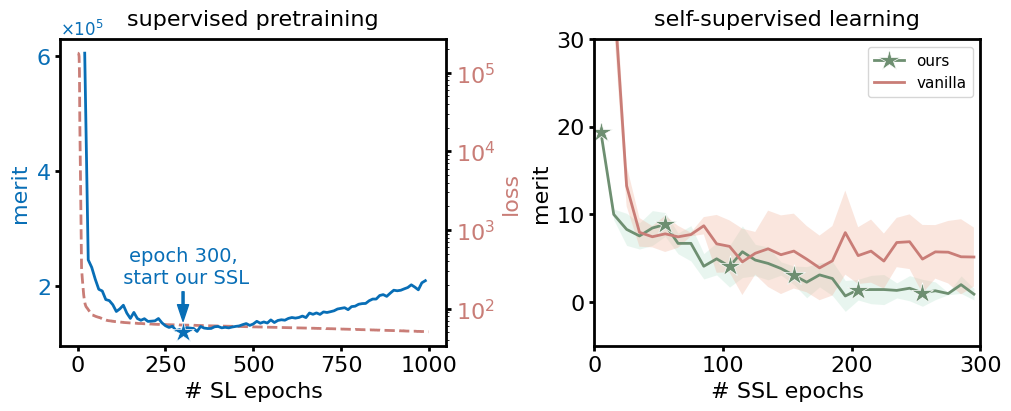

In [132]:
plot_learning_1x2(processed_data, main_result_path, BASE_DIR)